# AGENTS026 — UC-4 Alert Storm Correlation
**NetworkX graph clustering groups correlated alerts → single consolidated RCA call to GPU**

- Cell 1: Imports & config
- Cell 2: Alert ingestion (live anomalies + synthetic storm)
- Cell 3: Correlation graph builder (NetworkX)
- Cell 4: Graph clustering → incident groups
- Cell 5: GPU consolidated RCA
- Cell 6: LLM-as-Judge (evaluates RCA quality)
- Cell 7: Full UC-4 pipeline + results

In [1]:
# ── Cell 1: Imports & config ──────────────────────────────────────────────
import json, time
from pathlib import Path
from datetime import datetime, timezone
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from openai import OpenAI

METRICS_CSV     = Path("/workspace/shared/minicluster/live_metrics.csv")
AUDIT_FILE      = Path("/workspace/shared/audit_log.jsonl")
HITL_FILE       = Path("/workspace/shared/hitl_queue.jsonl")
UC4_RESULTS     = Path("/workspace/shared/uc4_alert_storm.jsonl")
JUDGE_RESULTS   = Path("/workspace/shared/uc4_judge_results.jsonl")

SERVICES = {"payments": 7001, "auth": 7002, "checkout": 7003, "fraud": 7004}
DEPENDENCIES = [
    ("checkout", "payments", "payment_auth"),
    ("checkout", "auth",     "session_check"),
    ("checkout", "fraud",    "fraud_screen"),
    ("payments", "auth",     "token_verify"),
    ("fraud",    "payments", "risk_signal"),
    ("auth",     "payments", "auth_confirm"),
]
THRESHOLDS = {
    "cpu_utilization": ("CPU %",       70.0),
    "latency_p95_ms":  ("Latency p95", 500.0),
    "error_rate":      ("Error rate",  0.05),
    "mem_mb":          ("Memory",      1800),
}

llm = OpenAI(base_url="http://localhost:8000/v1", api_key="abc-123")

def ts(): return datetime.now(timezone.utc).isoformat()
def write_log(path, event):
    path.parent.mkdir(parents=True, exist_ok=True)
    with open(path, "a") as f: f.write(json.dumps(event, default=str) + "\n")

print("✅ Cell 1 ready")

✅ Cell 1 ready


In [2]:
# ── Cell 2: Alert ingestion ───────────────────────────────────────────────
# Reads live anomalies; if <5, supplements with synthetic storm for demo

def get_live_alerts():
    alerts = []
    if not METRICS_CSV.exists(): return alerts
    df = pd.read_csv(METRICS_CSV, parse_dates=["timestamp"])
    latest = df.sort_values("timestamp").groupby("service").last().reset_index()
    alert_id = 1
    for _, row in latest.iterrows():
        for col, (label, thresh) in THRESHOLDS.items():
            val = float(row[col])
            if val > thresh:
                alerts.append({
                    "alert_id":  f"ALT-{alert_id:03d}",
                    "service":   row["service"],
                    "metric":    col,
                    "label":     label,
                    "value":     round(val, 4),
                    "threshold": thresh,
                    "severity":  "HIGH" if val > thresh * 1.5 else "WARN",
                    "timestamp": str(row["timestamp"]),
                    "node":      row.get("node", "?"),
                })
                alert_id += 1
    return alerts

SYNTHETIC_STORM = [
    {"alert_id":"ALT-001","service":"payments","metric":"latency_p95_ms","label":"Latency p95","value":820,"threshold":500,"severity":"HIGH","node":"node-1","timestamp":ts()},
    {"alert_id":"ALT-002","service":"payments","metric":"error_rate",   "label":"Error rate", "value":0.24,"threshold":0.05,"severity":"HIGH","node":"node-1","timestamp":ts()},
    {"alert_id":"ALT-003","service":"auth",    "metric":"latency_p95_ms","label":"Latency p95","value":640,"threshold":500,"severity":"WARN","node":"node-1","timestamp":ts()},
    {"alert_id":"ALT-004","service":"auth",    "metric":"error_rate",   "label":"Error rate", "value":0.38,"threshold":0.05,"severity":"HIGH","node":"node-1","timestamp":ts()},
    {"alert_id":"ALT-005","service":"checkout","metric":"latency_p95_ms","label":"Latency p95","value":560,"threshold":500,"severity":"WARN","node":"node-2","timestamp":ts()},
    {"alert_id":"ALT-006","service":"checkout","metric":"error_rate",   "label":"Error rate", "value":0.19,"threshold":0.05,"severity":"HIGH","node":"node-2","timestamp":ts()},
    {"alert_id":"ALT-007","service":"fraud",   "metric":"cpu_utilization","label":"CPU %",     "value":88,  "threshold":70,  "severity":"HIGH","node":"node-2","timestamp":ts()},
    {"alert_id":"ALT-008","service":"fraud",   "metric":"latency_p95_ms","label":"Latency p95","value":920,"threshold":500,"severity":"HIGH","node":"node-2","timestamp":ts()},
    {"alert_id":"ALT-009","service":"payments","metric":"cpu_utilization","label":"CPU %",     "value":78,  "threshold":70,  "severity":"WARN","node":"node-1","timestamp":ts()},
    {"alert_id":"ALT-010","service":"auth",    "metric":"cpu_utilization","label":"CPU %",     "value":74,  "threshold":70,  "severity":"WARN","node":"node-1","timestamp":ts()},
]

live_alerts = get_live_alerts()
if len(live_alerts) >= 5:
    ALL_ALERTS = live_alerts
    print(f"Using {len(ALL_ALERTS)} LIVE alerts")
else:
    ALL_ALERTS = SYNTHETIC_STORM
    print(f"Only {len(live_alerts)} live alerts — using synthetic storm of {len(ALL_ALERTS)} alerts")
    print("(Inject SC-05 via Chaos Scheduler to generate real alert storms)")

print(f"\nAlert breakdown:")
for a in ALL_ALERTS:
    sev = "🔴" if a["severity"]=="HIGH" else "🟡"
    print(f"  {sev} {a['alert_id']} | {a['service']:10s} | {a['label']:15s} | {a['value']}")

Only 4 live alerts — using synthetic storm of 10 alerts
(Inject SC-05 via Chaos Scheduler to generate real alert storms)

Alert breakdown:
  🔴 ALT-001 | payments   | Latency p95     | 820
  🔴 ALT-002 | payments   | Error rate      | 0.24
  🟡 ALT-003 | auth       | Latency p95     | 640
  🔴 ALT-004 | auth       | Error rate      | 0.38
  🟡 ALT-005 | checkout   | Latency p95     | 560
  🔴 ALT-006 | checkout   | Error rate      | 0.19
  🔴 ALT-007 | fraud      | CPU %           | 88
  🔴 ALT-008 | fraud      | Latency p95     | 920
  🟡 ALT-009 | payments   | CPU %           | 78
  🟡 ALT-010 | auth       | CPU %           | 74


Correlation graph:
  Nodes (alerted services): 4
  Edges (correlated paths): 5

  fraud     : 2 alerts (2 HIGH)
  payments  : 3 alerts (2 HIGH)
  checkout  : 2 alerts (1 HIGH)
  auth      : 3 alerts (1 HIGH)

  fraud ←→ checkout via fraud_screen (weight=4)
  fraud ←→ payments via risk_signal (weight=5)
  payments ←→ checkout via payment_auth (weight=5)
  payments ←→ auth via auth_confirm (weight=6)
  checkout ←→ auth via session_check (weight=5)


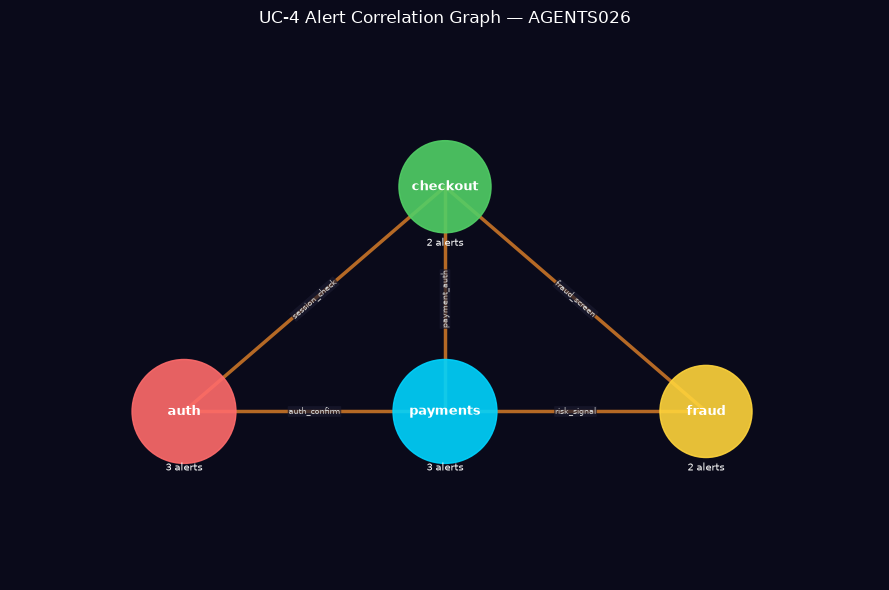


✅ Correlation graph saved to /workspace/shared/uc4_correlation_graph.png


In [3]:
# ── Cell 3: Correlation graph builder ────────────────────────────────────
# Nodes = services with alerts; edges = dependency relationships between them
# Edge weight = how many alerts are on both ends

def build_correlation_graph(alerts):
    G = nx.Graph()

    # Add all alerted services as nodes
    affected = set(a["service"] for a in alerts)
    for svc in affected:
        svc_alerts = [a for a in alerts if a["service"] == svc]
        high_count = sum(1 for a in svc_alerts if a["severity"] == "HIGH")
        G.add_node(svc, alert_count=len(svc_alerts), high_count=high_count,
                   alerts=svc_alerts)

    # Add edges from dependency graph where BOTH ends have alerts
    for src, dst, dep_name in DEPENDENCIES:
        if src in affected and dst in affected:
            src_alerts = len([a for a in alerts if a["service"] == src])
            dst_alerts = len([a for a in alerts if a["service"] == dst])
            weight = src_alerts + dst_alerts
            G.add_edge(src, dst, dependency=dep_name, weight=weight,
                       label=dep_name)

    return G

G = build_correlation_graph(ALL_ALERTS)

print(f"Correlation graph:")
print(f"  Nodes (alerted services): {G.number_of_nodes()}")
print(f"  Edges (correlated paths): {G.number_of_edges()}")
print()
for node, data in G.nodes(data=True):
    print(f"  {node:10s}: {data['alert_count']} alerts ({data['high_count']} HIGH)")
print()
for src, dst, data in G.edges(data=True):
    print(f"  {src} ←→ {dst} via {data['dependency']} (weight={data['weight']})")

# Visualise the graph
SVC_COLORS = {"payments": "#00d4ff", "auth": "#ff6b6b",
              "checkout": "#51cf66",  "fraud": "#ffd43b"}
pos = {"checkout": (0, 1.2), "auth": (-1.5, 0), "payments": (0, 0), "fraud": (1.5, 0)}

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("#0a0a1a"); ax.set_facecolor("#0a0a1a")
ax.set_xlim(-2.5, 2.5); ax.set_ylim(-0.9, 2.0); ax.axis("off")

node_colors = [SVC_COLORS.get(n, "#aaa") for n in G.nodes()]
node_sizes  = [G.nodes[n]["alert_count"] * 1200 + 2000 for n in G.nodes()]

nx.draw_networkx_nodes(G, pos, ax=ax, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#ff922b", width=2.5, alpha=0.7)
nx.draw_networkx_labels(G, pos, ax=ax, font_color="white", font_size=9, font_weight="bold")
edge_labels = {(s,d): data["dependency"] for s,d,data in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, ax=ax,
    font_color="#cccccc", font_size=6,
    bbox=dict(boxstyle="round,pad=0.1", facecolor="#1a1a2e", alpha=0.7, edgecolor="none"))

for node in G.nodes():
    x, y = pos[node]
    cnt = G.nodes[node]["alert_count"]
    ax.text(x, y-0.30, f"{cnt} alerts", ha="center", va="center",
            fontsize=7, color="#ffffff", zorder=10)

ax.set_title("UC-4 Alert Correlation Graph — AGENTS026", color="white", fontsize=12, pad=10)
plt.tight_layout()
graph_path = Path("/workspace/shared/uc4_correlation_graph.png")
plt.savefig(str(graph_path), dpi=120, bbox_inches="tight", facecolor=fig.get_facecolor())
plt.show()
print(f"\n✅ Correlation graph saved to {graph_path}")

In [4]:
# ── Cell 4: Graph clustering → incident groups ────────────────────────────
# Connected components = correlated incident groups
# Each component gets ONE consolidated RCA call (not one per alert)

components = list(nx.connected_components(G))
print(f"UC-4 Alert Grouping Results:")
print(f"  Total alerts  : {len(ALL_ALERTS)}")
print(f"  Alert groups  : {len(components)} (was {len(ALL_ALERTS)} before correlation)")
print(f"  Reduction     : {(1 - len(components)/len(ALL_ALERTS))*100:.0f}% fewer RCA calls")
print()

INCIDENT_GROUPS = []
for i, component in enumerate(components):
    services_in_group = list(component)
    group_alerts = [a for a in ALL_ALERTS if a["service"] in component]
    high_alerts  = [a for a in group_alerts if a["severity"] == "HIGH"]

    # Find the root node (highest degree = most connections = likely root cause)
    subgraph = G.subgraph(component)
    if subgraph.number_of_edges() > 0:
        root_candidate = max(component, key=lambda n: subgraph.degree(n))
    else:
        # Isolated node — itself is the root
        root_candidate = list(component)[0]

    group = {
        "group_id":        f"GRP-{i+1:02d}",
        "services":        services_in_group,
        "root_candidate":  root_candidate,
        "total_alerts":    len(group_alerts),
        "high_alerts":     len(high_alerts),
        "alerts":          group_alerts,
        "severity":        "CRITICAL" if len(high_alerts) >= 3 else ("HIGH" if high_alerts else "WARN"),
    }
    INCIDENT_GROUPS.append(group)

    sev_icon = "💀" if group["severity"]=="CRITICAL" else ("🔴" if group["severity"]=="HIGH" else "🟡")
    print(f"  {sev_icon} {group['group_id']}: {' + '.join(services_in_group)}")
    print(f"       Alerts: {len(group_alerts)} total, {len(high_alerts)} HIGH")
    print(f"       Root candidate: {root_candidate}")
    print()

print(f"✅ Cell 4 complete — {len(INCIDENT_GROUPS)} groups ready for GPU RCA")

UC-4 Alert Grouping Results:
  Total alerts  : 10
  Alert groups  : 1 (was 10 before correlation)
  Reduction     : 90% fewer RCA calls

  💀 GRP-01: payments + auth + checkout + fraud
       Alerts: 10 total, 6 HIGH
       Root candidate: payments

✅ Cell 4 complete — 1 groups ready for GPU RCA


In [5]:
# ── Cell 5: GPU consolidated RCA ──────────────────────────────────────────
# ONE LLM call per group, not per alert

def gpu_group_rca(group):
    alert_summary = "\n".join(
        f"  {a['alert_id']} | {a['service']:10s} | {a['label']:15s} | "
        f"value={a['value']} threshold={a['threshold']} severity={a['severity']}"
        for a in group["alerts"]
    )

    prompt = f"""You are a senior banking SRE. An alert storm has been grouped by dependency graph analysis.

INCIDENT GROUP: {group['group_id']}
Services affected: {', '.join(group['services'])}
Root cause candidate (highest graph degree): {group['root_candidate']}
Severity: {group['severity']}

CORRELATED ALERTS ({group['total_alerts']} total, {group['high_alerts']} HIGH):
{alert_summary}

Dependency paths between these services:
{chr(10).join(f'  {s} → {d} via {dep}' for s,d,dep in DEPENDENCIES if s in group['services'] and d in group['services'])}

Provide a consolidated RCA for this group. The alerts are correlated — diagnose ONE root cause.
Format:
ROOT_CAUSE: <single root cause explaining all alerts in group>
PROPAGATION: <how fault spread through the dependency graph>
PRIORITY_ACTION: <single most important remediation step>
ESTIMATED_RESOLUTION: <time estimate>
CONFIDENCE: <HIGH|MEDIUM|LOW>"""

    t0 = time.time()
    resp = llm.chat.completions.create(
        model="Qwen3-30B-A3B",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.2, max_tokens=250,
        extra_body={"chat_template_kwargs": {"enable_thinking": False}}
    )
    elapsed = time.time() - t0
    return resp.choices[0].message.content.strip(), elapsed

print("Running GPU consolidated RCA on each incident group...\n")
RCA_RESULTS = []

for group in INCIDENT_GROUPS:
    print(f"🧠 {group['group_id']} — {group['severity']} — {', '.join(group['services'])}")
    rca, elapsed = gpu_group_rca(group)
    result = {**group, "rca": rca, "rca_time_secs": round(elapsed,2), "timestamp": ts()}
    RCA_RESULTS.append(result)
    write_log(UC4_RESULTS, {"event_type": "UC4_RCA_COMPLETE", **result})
    write_log(AUDIT_FILE,  {"event_type": "UC4_RCA_COMPLETE", **result})

    print(f"   Time: {elapsed:.2f}s")
    print(f"   {rca[:120]}...")
    print()

print(f"✅ UC-4 RCA complete — {len(RCA_RESULTS)} groups diagnosed")
print(f"   LLM calls: {len(RCA_RESULTS)} (vs {len(ALL_ALERTS)} if each alert called independently)")

Running GPU consolidated RCA on each incident group...

🧠 GRP-01 — CRITICAL — payments, auth, checkout, fraud
   Time: 1.56s
   ROOT_CAUSE: **payments service is experiencing high error rates and latency, causing cascading failures across dependent...

✅ UC-4 RCA complete — 1 groups diagnosed
   LLM calls: 1 (vs 10 if each alert called independently)


In [6]:
# ── Cell 6: LLM-as-Judge ─────────────────────────────────────────────────
# Separate LLM call evaluates quality of each RCA output
# Criteria: accuracy, actionability, specificity, banking domain relevance

def llm_judge(group, rca_text):
    prompt = f"""You are an expert banking SRE evaluator assessing the quality of an AI-generated RCA.

ALERT GROUP:
Services: {', '.join(group['services'])}
Alert count: {group['total_alerts']}
Root candidate: {group['root_candidate']}

AI GENERATED RCA:
{rca_text}

Evaluate on these criteria (score 1-5 each):
1. SPECIFICITY: Does it name specific services/metrics, not vague?
2. ACTIONABILITY: Is the priority action concrete and executable?
3. CAUSALITY: Does the propagation explanation make technical sense?
4. BANKING_RELEVANCE: Is the language/reasoning appropriate for financial services?
5. COMPLETENESS: Does it address all affected services in the group?

Respond ONLY in JSON:
{{"specificity":N,"actionability":N,"causality":N,"banking_relevance":N,"completeness":N,
"overall":N,"verdict":"PASS|FAIL|REVIEW","feedback":"one sentence"}}"""

    resp = llm.chat.completions.create(
        model="Qwen3-30B-A3B",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.1, max_tokens=200,
        extra_body={"chat_template_kwargs": {"enable_thinking": False}}
    )
    raw = resp.choices[0].message.content.strip().replace("```json","").replace("```","").strip()
    try:
        return json.loads(raw)
    except:
        return {"verdict": "PARSE_ERROR", "raw": raw, "overall": 0}

print("Running LLM-as-Judge on all RCA outputs...\n")
JUDGE_EVALS = []

for result in RCA_RESULTS:
    print(f"⚖️  Judging {result['group_id']}...")
    evaluation = llm_judge(result, result["rca"])
    eval_record = {
        "group_id":   result["group_id"],
        "services":   result["services"],
        "evaluation": evaluation,
        "timestamp":  ts()
    }
    JUDGE_EVALS.append(eval_record)
    write_log(JUDGE_RESULTS, {"event_type": "LLM_JUDGE", **eval_record})
    write_log(AUDIT_FILE,    {"event_type": "LLM_JUDGE", **eval_record})

    verdict  = evaluation.get("verdict","?")
    overall  = evaluation.get("overall", 0)
    feedback = evaluation.get("feedback","")
    icon = "✅" if verdict=="PASS" else ("⚠️" if verdict=="REVIEW" else "❌")
    print(f"   {icon} {verdict} | overall={overall}/5 | {feedback}")
    print()

avg_overall = sum(e["evaluation"].get("overall",0) for e in JUDGE_EVALS) / max(len(JUDGE_EVALS),1)
print(f"✅ LLM-as-Judge complete")
print(f"   Average overall score: {avg_overall:.1f}/5")
print(f"   PASS: {sum(1 for e in JUDGE_EVALS if e['evaluation'].get('verdict')=='PASS')}")
print(f"   REVIEW: {sum(1 for e in JUDGE_EVALS if e['evaluation'].get('verdict')=='REVIEW')}")
print(f"   FAIL: {sum(1 for e in JUDGE_EVALS if e['evaluation'].get('verdict')=='FAIL')}")

Running LLM-as-Judge on all RCA outputs...

⚖️  Judging GRP-01...
   ✅ PASS | overall=5/5 | The RCA is detailed, technically sound, and fully addresses the financial services context and impacted components.

✅ LLM-as-Judge complete
   Average overall score: 5.0/5
   PASS: 1
   REVIEW: 0
   FAIL: 0


In [7]:
# ── Cell 7: Full UC-4 pipeline + results ─────────────────────────────────

print("═" * 65)
print("UC-4 ALERT STORM CORRELATION — FULL RESULTS")
print("═" * 65)
print(f"  Input alerts   : {len(ALL_ALERTS)}")
print(f"  Incident groups: {len(INCIDENT_GROUPS)}")
print(f"  LLM calls used : {len(RCA_RESULTS)} (saved {len(ALL_ALERTS) - len(RCA_RESULTS)} calls)")
print(f"  Judge avg score: {avg_overall:.1f}/5")
print()

for result, eval_rec in zip(RCA_RESULTS, JUDGE_EVALS):
    ev  = eval_rec["evaluation"]
    icon = "✅" if ev.get("verdict")=="PASS" else ("⚠️" if ev.get("verdict")=="REVIEW" else "❌")
    print(f"{'─'*65}")
    print(f"{result['group_id']} [{result['severity']}] — {', '.join(result['services'])}")
    print(f"Root candidate : {result['root_candidate']}")
    print(f"RCA summary    :")
    for line in result["rca"].split("\n")[:5]:
        if line.strip(): print(f"  {line}")
    print(f"Judge verdict  : {icon} {ev.get('verdict')} ({ev.get('overall',0)}/5)")
    print(f"Feedback       : {ev.get('feedback','')}")
    print()

print("Results written to:")
print(f"  {UC4_RESULTS}")
print(f"  {JUDGE_RESULTS}")
print(f"  {AUDIT_FILE}")
print(f"  {Path('/workspace/shared/uc4_correlation_graph.png')}")

═════════════════════════════════════════════════════════════════
UC-4 ALERT STORM CORRELATION — FULL RESULTS
═════════════════════════════════════════════════════════════════
  Input alerts   : 10
  Incident groups: 1
  LLM calls used : 1 (saved 9 calls)
  Judge avg score: 5.0/5

─────────────────────────────────────────────────────────────────
GRP-01 [CRITICAL] — payments, auth, checkout, fraud
Root candidate : payments
RCA summary    :
  ROOT_CAUSE: **payments service is experiencing high error rates and latency, causing cascading failures across dependent services (auth, checkout, fraud).**
  PROPAGATION: The payments service is the central dependency for auth, checkout, and fraud. Its high error rate (24%) and increased latency (820ms p95) are causing timeouts and failures in downstream services. Auth is failing due to failed token verification from payments, checkout is failing due to payment and auth timeouts, and fraud is failing due to delayed risk signals from payments. Addit